# Bottle-Base Inspection — YOLO26 Detection Pipeline

**Goal.** Reframe the GOOD/FAULTY decision as object *detection* rather than whole-image
classification. A detector localizes each defect and gives us its **predicted box area** at
inference — which means we can apply the conditional-defect area thresholds *without* needing
defect annotations on the test set (the test set only ships the ROI box).

**Why this might beat the 0.963 classifier ceiling.** Three classifier architectures all capped
near F1=0.963. Their failure mode was the ~100-115 bottles where `contamination_dark` co-occurs
with `water_drop`/`foam`/`scuffing` and the conditional defects sit near their pixel-area
thresholds — signal the classifier couldn't resolve at 320px and couldn't measure (no area input).
A detector at **imgsz=1280** sees those patches at ~4x the linear resolution and *measures* area
directly. YOLO26 adds STAL (Small-Target-Aware Label assignment) + ProgLoss, both aimed at
small-object recall.

**Two honest caveats, kept visible on purpose:**
1. The detector must *find* the small defects to box them. If it can't localize `contamination_dark`,
   it will miss them — possibly doing **worse** than the classifier on exactly the hard cases.
   We won't know until it runs. That's the point: this run is a **test of a hypothesis**, not a
   guaranteed win.
2. The detection→binary conversion (apply area thresholds → aggregate to one label) is the
   highest-leverage knob in the whole notebook. The area thresholds live in `CONFIG`. Tune there.

**Comparability.** The evaluation cell builds the **same recall-floor table** you used for the
classifier, so YOLO results drop straight into your existing comparison.

---
Hardware target: single **NVIDIA RTX A5000 (24 GB)**. Defaults: `imgsz=1280, batch=16`.


## 0 — Environment

Uncomment the install if `ultralytics` is not already present. On a dedicated workstation, install the CUDA build of PyTorch that matches your driver *first*, then ultralytics, so pip does not pull a CPU-only torch.

In [14]:
# !pip install ultralytics  # installs torch as a dependency if missing — prefer installing
#                              # the correct CUDA torch build yourself BEFORE this line.

import ultralytics, torch, platform, tqdm
print("ultralytics:", ultralytics.__version__)
print("torch      :", torch.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))
    print("VRAM (GB)  :", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1))
print("python     :", platform.python_version())

ultralytics: 8.4.56
torch      : 2.12.0+cu130
CUDA avail : True
GPU        : NVIDIA RTX A5000
VRAM (GB)  : 25.3
python     : 3.13.9


## 1 — CONFIG  ⟵ **verify every value here before running anything below**

This is the only cell you should need to edit. Everything downstream reads from `CONFIG`.

The three label buckets and their pixel-area thresholds are transcribed from the project spec.
**Confirm the thresholds and category spellings match your COCO `categories` exactly** — a single
mismatched name silently drops that category from training and corrupts the binary decision.

In [22]:
from pathlib import Path

CONFIG = {
    # ── Paths (EDIT THESE to your workstation layout) ──────────────────────
    "images_dir":      Path("./1st-krones-vision-ai-challenge/train_images"),   # raw .png training images
    "coco_json":       Path("./1st-krones-vision-ai-challenge/train_annotations.json"),# COCO with defect boxes
    "test_images_dir": Path("./1st-krones-vision-ai-challenge/test_images"),     # for the submission cell
    "test_coco_json":  Path("./1st-krones-vision-ai-challenge/test_annotations_roi_only.json"),  # ROI-only is fine
    "work_dir":        Path("./1st-krones-vision-ai-challenge/yolo_ds"),         # YOLO dataset gets built here
    "runs_dir":        Path("./1st-krones-vision-ai-challenge/runs"),            # training outputs

    # ── Image geometry ─────────────────────────────────────────────────────
    "img_w": 1280,
    "img_h": 1024,

    # ── ROI category in COCO (used to crop, NOT a defect) ──────────────────
    "roi_category_id": 22,

    # ── Model / training (tuned for A5000 24GB) ────────────────────────────
    "model_name":  "yolo26n.pt",   # fallback: "yolo11n.pt" if 26n unavailable
    "imgsz":       1280,           # 1536→batch 8 for more detail; 960→batch 32 if OOM
    "batch":       16,
    "epochs":      120,
    "patience":    30,
    "seed":        42,
    "device":      0,

    # ── Split (bottle-level, leakage-safe) ─────────────────────────────────
    "val_frac":  0.15,
    "test_frac": 0.15,           # internal held-out test (NOT the competition test set)

    # ── Rare-category oversampling (image-level repeat factor) ─────────────
    # Images containing any of these get repeated in the TRAIN split only.
    "rare_categories": [
        "chip", "glass shard", "insect", "liquid", "label",
        "break / crack", "glass imperfection", "yeast residue",
        "foreign object - washing machine", "foreign object - manual cleaning",
        "no base visible",
    ],
    "rare_repeat_factor": 4,     # how many times to repeat a rare-containing train image

    # ── LABEL BUCKETS (verbatim from spec — CONFIRM) ───────────────────────
    # GOOD: never faulty on their own.
    "good_labels": {
        "embossing", "foam residue", "no fault", "water drop",
    },
    # CONDITIONAL: faulty ONLY if box area (px) exceeds the threshold.
    "conditional_thresholds": {
        "air bubble":          500,
        "chip":                200,
        "contamination light": 180,
        "glass imperfection":  100,
        "scuffing":            75000,
        "scuffing heavy":      1200,
    },
    # ALWAYS-FAULTY: faulty regardless of area.
    "always_faulty_labels": {
        "break / crack", "circlip", "contamination dark", "crown cap",
        "foil / semitransparent", "foreign object - manual cleaning",
        "foreign object - washing machine", "glass shard", "insect",
        "label", "liquid", "mold", "no base visible", "paint residue",
        "straw", "yeast residue",
    },
}

# Convenience: normalised name matching (lowercase, collapse separators/spaces)
def norm_name(s: str) -> str:
    return " ".join(s.lower().replace("_", " ").replace("/", " / ").split())

CONFIG["work_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["runs_dir"].mkdir(parents=True, exist_ok=True)
print("CONFIG loaded. Verify the three label buckets and thresholds above.")

CONFIG loaded. Verify the three label buckets and thresholds above.


## 2 — Load COCO, build the class list, sanity-check categories

We detect every defect category as its **own YOLO class** (multi-class detection), then collapse
to GOOD/FAULTY *after* prediction using the area rule. Detecting per-category — rather than a
single "defect" class — lets the model specialize and lets the binary rule apply the right
threshold per category.

This cell also **flags any COCO category that is not in any bucket**, which is the most common
silent error.

In [18]:
import json
from collections import defaultdict, Counter

with open(CONFIG["coco_json"]) as f:
    coco = json.load(f)

id_to_file = {im["id"]: Path(im["file_name"]).name for im in coco["images"]}
file_to_wh = {Path(im["file_name"]).name: (im.get("width", CONFIG["img_w"]),
                                            im.get("height", CONFIG["img_h"]))
              for im in coco["images"]}
catid_to_name = {c["id"]: c["name"] for c in coco["categories"]}

# Every bucket name, normalised
all_bucket_names = (
    {norm_name(x) for x in CONFIG["good_labels"]}
    | {norm_name(x) for x in CONFIG["conditional_thresholds"]}
    | {norm_name(x) for x in CONFIG["always_faulty_labels"]}
)

# Which COCO categories are defects (exclude the ROI box) and are they all bucketed?
defect_catids = []
unbucketed = []
for cid, cname in catid_to_name.items():
    if cid == CONFIG["roi_category_id"]:
        continue
    if norm_name(cname) in all_bucket_names:
        defect_catids.append(cid)
    else:
        unbucketed.append((cid, cname))

defect_catids = sorted(defect_catids)
# Stable YOLO class index per defect category
CLASS_NAMES = [catid_to_name[c] for c in defect_catids]
catid_to_yolo = {c: i for i, c in enumerate(defect_catids)}
yolo_to_norm  = {i: norm_name(catid_to_name[c]) for c, i in catid_to_yolo.items()}

print(f"Defect classes for YOLO: {len(CLASS_NAMES)}")
for i, n in enumerate(CLASS_NAMES):
    print(f"  {i:2d}  {n}")

if unbucketed:
    print("\n*** WARNING — COCO categories NOT in any bucket (will be IGNORED): ***")
    for cid, cname in unbucketed:
        print(f"    id={cid}  name={cname!r}")
    print("Fix CONFIG buckets if any of these are real defects.")
else:
    print("\nAll defect categories are bucketed. Good.")

Defect classes for YOLO: 26
   0  Air bubble
   1  Break / Crack
   2  Chip
   3  Circlip
   4  Contamination dark
   5  Contamination light
   6  Crown cap
   7  Embossing
   8  Foam residue
   9  Foil / Semitransparent
  10  Foreign object - manual cleaning
  11  Foreign object - washing machine
  12  Glass imperfection
  13  Glass shard
  14  Insect
  15  Label
  16  Liquid
  17  Mold
  18  No base visible
  19  No fault
  20  Paint residue
  21  Scuffing
  22  Scuffing heavy
  23  Straw
  24  Water drop
  25  Yeast residue

All defect categories are bucketed. Good.


## 3 — Per-image annotation inventory + the GROUND-TRUTH binary label

For evaluation we need the *true* GOOD/FAULTY label per image, derived by the same area rule the
detector will later apply to *predictions*. This is the reference the recall-floor table scores against.

In [19]:
# Gather annotations per image
img_anns = defaultdict(list)  # filename -> list of (catid, bbox[x,y,w,h], area)
for a in coco["annotations"]:
    if a["category_id"] == CONFIG["roi_category_id"]:
        continue
    fname = id_to_file.get(a["image_id"])
    if fname is None:
        continue
    bbox = a.get("bbox")
    if not bbox or len(bbox) != 4:
        continue
    area = a.get("area")
    if area is None:
        area = bbox[2] * bbox[3]
    img_anns[fname].append((a["category_id"], bbox, float(area)))

def resolve_binary_label(anns) -> int:
    """Apply the 3-tier rule to a list of (catid, bbox, area). Returns 1=FAULTY, 0=GOOD."""
    cond = {norm_name(k): v for k, v in CONFIG["conditional_thresholds"].items()}
    always = {norm_name(x) for x in CONFIG["always_faulty_labels"]}
    for catid, _bbox, area in anns:
        nm = norm_name(catid_to_name.get(catid, ""))
        if nm in always:
            return 1
        if nm in cond and area > cond[nm]:
            return 1
    return 0

# All images that appear in COCO (defect-bearing or not)
all_files = sorted(file_to_wh.keys())
true_binary = {f: resolve_binary_label(img_anns.get(f, [])) for f in all_files}

n_faulty = sum(true_binary.values())
n_good   = len(true_binary) - n_faulty
print(f"Ground-truth binary: GOOD={n_good} ({100*n_good/len(true_binary):.1f}%) | "
      f"FAULTY={n_faulty} ({100*n_faulty/len(true_binary):.1f}%) | total={len(true_binary)}")

Ground-truth binary: GOOD=14797 (41.9%) | FAULTY=20545 (58.1%) | total=35342


## 4 — Leakage-safe split

Stratify by the binary label so GOOD/FAULTY ratios match across splits. The split is keyed on
**filename**; if your dataset has multiple shots of the same *physical* bottle under different IDs,
replace `split_key` with a bottle identifier so no physical bottle straddles train/val/test.
With the data as given (one row per image), filename is the unit.

In [20]:
from sklearn.model_selection import train_test_split

files = all_files
labels = [true_binary[f] for f in files]

# train vs (val+test)
train_files, temp_files, _, temp_labels = train_test_split(
    files, labels, test_size=CONFIG["val_frac"] + CONFIG["test_frac"],
    stratify=labels, random_state=CONFIG["seed"])
# val vs test inside temp
rel_test = CONFIG["test_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
val_files, test_files = train_test_split(
    temp_files, test_size=rel_test, stratify=temp_labels, random_state=CONFIG["seed"])

split_of = {}
for f in train_files: split_of[f] = "train"
for f in val_files:   split_of[f] = "val"
for f in test_files:  split_of[f] = "test"

for name, fs in [("train", train_files), ("val", val_files), ("test", test_files)]:
    nf = sum(true_binary[f] for f in fs)
    print(f"{name:5s}: {len(fs):5d}  FAULTY={nf} ({100*nf/max(len(fs),1):.1f}%)")

train: 24739  FAULTY=14381 (58.1%)
val  :  5301  FAULTY=3082 (58.1%)
test :  5302  FAULTY=3082 (58.1%)


## 5 — Write YOLO-format dataset (labels + images) with rare-category oversampling

YOLO wants one `.txt` per image (`class cx cy w h`, normalised) and a directory layout.
Oversampling is **train-only** and done by physically duplicating image+label pairs with a
suffixed name (`__dupN`) so the Ultralytics sampler sees them as extra examples. We never
duplicate into val/test — that would inflate the score.

In [8]:
import shutil, os

import tqdm

ds = CONFIG["work_dir"]
for sub in ["images/train", "images/val", "images/test",
            "labels/train", "labels/val", "labels/test"]:
    (ds / sub).mkdir(parents=True, exist_ok=True)

rare_norm = {norm_name(x) for x in CONFIG["rare_categories"]}

def has_rare(fname) -> bool:
    for catid, _b, _a in img_anns.get(fname, []):
        if norm_name(catid_to_name.get(catid, "")) in rare_norm:
            return True
    return False

def yolo_lines(fname):
    """Build YOLO label lines for an image from its COCO boxes."""
    w_img, h_img = file_to_wh.get(fname, (CONFIG["img_w"], CONFIG["img_h"]))
    lines = []
    for catid, bbox, _area in img_anns.get(fname, []):
        if catid not in catid_to_yolo:
            continue  # unbucketed/ignored category
        x, y, bw, bh = bbox
        cx = (x + bw / 2) / w_img
        cy = (y + bh / 2) / h_img
        nw = bw / w_img
        nh = bh / h_img
        # clip to [0,1]
        cx, cy = min(max(cx, 0), 1), min(max(cy, 0), 1)
        nw, nh = min(max(nw, 0), 1), min(max(nh, 0), 1)
        lines.append(f"{catid_to_yolo[catid]} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
    return lines

def link_or_copy(src, dst):
    if dst.exists():
        return
    try:
        os.symlink(src, dst)          # cheap; falls back to copy if FS disallows
    except OSError:
        shutil.copy2(src, dst)

written = Counter()
for fname in tqdm.tqdm(files):
    split = split_of[fname]
    src_img = CONFIG["images_dir"] / fname
    if not src_img.exists():
        continue  # skip missing image rather than crash the whole build
    lines = yolo_lines(fname)

    # base copy
    stem = Path(fname).stem
    link_or_copy(src_img, ds / f"images/{split}/{fname}")
    (ds / f"labels/{split}/{stem}.txt").write_text("\n".join(lines))
    written[split] += 1

    # rare oversampling: train only
    if split == "train" and has_rare(fname):
        for k in range(1, CONFIG["rare_repeat_factor"]):
            dup = f"{stem}__dup{k}{Path(fname).suffix}"
            link_or_copy(src_img, ds / f"images/train/{dup}")
            (ds / f"labels/train/{Path(dup).stem}.txt").write_text("\n".join(lines))
            written["train_dup"] += 1

print("Written:", dict(written))
print(f"Train images incl. duplicates: {written['train'] + written['train_dup']}")

100%|██████████| 35342/35342 [00:04<00:00, 8416.62it/s]

Written: {'train': 24739, 'val': 5301, 'test': 5302, 'train_dup': 24063}
Train images incl. duplicates: 48802


## 6 — Dataset YAML

In [ ]:
import yaml

data_yaml = {
    "path":  str(ds),
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}
yaml_path = ds / "bottle.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)
print(yaml_path.read_text())

## 7 — Train

Augmentation notes for *small-defect* detection: keep mosaic on early (helps small-object
density) but `close_mosaic` for the final epochs so the model settles on real layouts. Bottle
bases are rotationally symmetric, so full rotation + flips are valid and free augmentation.
We keep HSV jitter modest — heavy colour shifts can turn a clean bottle into a fake
`contamination_light`, the same mistake the classifier augmentations made.

YOLO26 is NMS-free and turns on STAL/ProgLoss by default, so no special small-object flags
are required beyond the high `imgsz`.

In [11]:
import shutil, os
from collections import Counter
from pathlib import Path

ds = CONFIG["work_dir"]

# Wipe and recreate the dataset dirs so no broken symlinks linger
if ds.exists():
    shutil.rmtree(ds)
for sub in ["images/train", "images/val", "images/test",
            "labels/train", "labels/val", "labels/test"]:
    (ds / sub).mkdir(parents=True, exist_ok=True)

# Resolve the source dir to an ABSOLUTE path so there is no ambiguity
images_root = CONFIG["images_dir"].resolve()
print("Copying from:", images_root)
assert images_root.exists(), f"images_dir does not exist: {images_root}"

written = Counter()
missing = 0
for fname in files:
    split   = split_of[fname]
    src_img = images_root / fname
    if not src_img.exists():
        missing += 1
        continue
    lines = yolo_lines(fname)
    stem  = Path(fname).stem

    # COPY (not symlink) — robust against any path resolution issue
    shutil.copy2(src_img, ds / f"images/{split}/{fname}")
    (ds / f"labels/{split}/{stem}.txt").write_text("\n".join(lines))
    written[split] += 1

    # rare oversampling: train only
    if split == "train" and has_rare(fname):
        for k in range(1, CONFIG["rare_repeat_factor"]):
            dup = f"{stem}__dup{k}{Path(fname).suffix}"
            shutil.copy2(src_img, ds / f"images/train/{dup}")
            (ds / f"labels/train/{Path(dup).stem}.txt").write_text("\n".join(lines))
            written["train_dup"] += 1

print("Written:", dict(written))
print("Missing source images skipped:", missing)
print(f"Train total incl. dups: {written['train'] + written['train_dup']}")

# Sanity check: confirm files actually exist and are readable
import random
sample = random.sample(
    [p for p in (ds/'images/train').iterdir()], min(5, written['train']+written['train_dup'])
)
for p in sample:
    print("OK" if p.exists() and p.stat().st_size > 0 else "BROKEN", p.name, p.stat().st_size, "bytes")

Copying from: /home/dll0706/Documents/Bakwowi_Junior_CV_Project/1st-krones-vision-ai-challenge/train_images
Written: {'train': 24739, 'val': 5301, 'test': 5302, 'train_dup': 24063}
Missing source images skipped: 0
Train total incl. dups: 48802
OK 5144eeae-0b14-4154-a3a7-7c7f8299c37e_000000013137.png 511084 bytes
OK 48a20ef7-af82-4f7d-a571-7fff8b9bae49_000000029478.png 604126 bytes
OK 05217d8a-0753-4f4d-bb04-2a480cdf3069_000000011947__dup1.png 582680 bytes
OK b5757850-3fdf-4c1d-ac10-ddeb0a788543_000000004049__dup2.png 497419 bytes
OK ee89f843-b997-4ac8-adcd-497ff3958d07_000000003974__dup1.png 68826 bytes


In [14]:
from ultralytics import YOLO

model = YOLO(CONFIG["model_name"])

train_args = dict(
    data        = str(yaml_path),
    epochs      = CONFIG["epochs"],
    imgsz       = CONFIG["imgsz"],
    batch       = CONFIG["batch"],
    device      = CONFIG["device"],
    seed        = CONFIG["seed"],
    patience    = CONFIG["patience"],
    project     = str(CONFIG["runs_dir"]),
    name        = "yolo26n_bottle_1280",
    exist_ok    = True,

    # optimizer / schedule
    optimizer   = "auto",     # YOLO26 picks MuSGD where appropriate
    lr0         = 0.01,
    lrf         = 0.01,
    warmup_epochs = 3.0,
    cos_lr      = True,

    # augmentation — tuned for symmetric bottle bases + small defects
    degrees     = 180.0,      # full rotation valid (radial symmetry)
    fliplr      = 0.5,
    flipud      = 0.5,
    translate   = 0.05,
    scale       = 0.3,
    hsv_h       = 0.010,      # modest — avoid faking contamination_light
    hsv_s       = 0.30,
    hsv_v       = 0.30,
    mosaic      = 1.0,
    close_mosaic= 15,         # disable mosaic for last 15 epochs
    mixup       = 0.0,        # off: blending defects across bottles muddies the area signal

    plots       = True,
    val         = True,
)

results = model.train(**train_args)
print("Training done. Best weights:", model.trainer.best)

New https://pypi.org/project/ultralytics/8.4.58 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.13.9 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX A5000, 24114MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=1st-krones-vision-ai-challenge/yolo_ds/bottle.yaml, degrees=180.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.3, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.

/home/dll0706/Documents/Bakwowi_Junior_CV_Project/.conda_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1554.2±1089.8 MB/s, size: 582.2 KB)
val: Scanning /home/dll0706/Documents/Bakwowi_Junior_CV_Project/1st-krones-vision-ai-challenge/yolo_ds/labels/val... 5301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5301/5301 1.2Kit/s 4.4s<0.0s
val: New cache created: /home/dll0706/Documents/Bakwowi_Junior_CV_Project/1st-krones-vision-ai-challenge/yolo_ds/labels/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: MuSGD(lr=0.01, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to /home/dll0706/Documents/Bakwowi_Junior_CV_Project/runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/labels.jpg... 
Image sizes 1280 train, 1280 val
Using 8 dataloader workers
Logging results to /home/dll0706/Documents/Bakwowi_Junior_CV_Project/runs/detect/1st-kron

In [2]:
import gc, torch
if 'model' in dir() and getattr(model, 'trainer', None) is not None:
    model.trainer = None
gc.collect()
torch.cuda.empty_cache()
print("Free VRAM (GB):", round(torch.cuda.mem_get_info()[0]/1e9, 1))

Free VRAM (GB): 25.0


## 8 — Detection → BINARY conversion (the core logic)

For each image: run the detector, then apply the 3-tier rule to the **predicted** boxes —
always-faulty class present at any confidence ≥ τ ⇒ FAULTY; conditional class with predicted
**box area (in original pixels) > threshold** ⇒ FAULTY; else GOOD.

Two tunable knobs live here and they dominate the result:
- `conf` (detection confidence floor before a box counts) — sweepable, like your classifier τ.
- the per-category area thresholds (already in CONFIG) applied to predicted-box area.

In [11]:
test_images_path = Path('./1st-krones-vision-ai-challenge/yolo_ds/images/test')

In [8]:
import numpy as np
from PIL import Image

def is_no_base_visible(image_path, mean_thresh=25, dark_frac_thresh=0.85):
    """
    'No base visible' = the frame is overwhelmingly dark (base missing).
    Cheap pixel rule, applied BEFORE the detector. Returns True if the image
    is mostly black, which the spec treats as always-FAULTY.
    Tune mean_thresh / dark_frac_thresh on a few known examples.
    """
    im = np.asarray(Image.open(image_path).convert("L"), dtype=np.float32)
    mean_intensity = im.mean()
    dark_fraction  = (im < 40).mean()
    return mean_intensity < mean_thresh or dark_fraction > dark_frac_thresh

In [27]:
# Sanity-check the threshold before wiring it into the pipeline
known_no_base = [  # the black-frame filenames from your hard-FAULTY panel
    "fe4676b3-cc09-4f00-8297-c4d7364af670_000000020395.png",   # fill in the real names
]
# known_good = good_sel  # from the visualization cell, if still in memory

for f in known_no_base:
    print("no_base?", is_no_base_visible(CONFIG["images_dir"]/f), f)

no_base? False fe4676b3-cc09-4f00-8297-c4d7364af670_000000020395.png


In [9]:
import numpy as np

cond_norm   = {norm_name(k): v for k, v in CONFIG["conditional_thresholds"].items()}
always_norm = {norm_name(x) for x in CONFIG["always_faulty_labels"]}

# Per-class confidence floors. Classes not listed use the global floor.
# Low floors for the three hard-to-detect always/conditional defects so
# under-confident boxes still count; everything else stays at the swept conf.
PER_CLASS_CONF = {
    "contamination dark":  0.02,
    "contamination light": 0.02,
    "mold":                0.02,
}

def predict_binary_for_files(model, file_list, images_root, conf=0.25, iou=0.6,
                             imgsz=None, return_scores=False, chunk=16):
    imgsz = imgsz or CONFIG["imgsz"]
    out = {}
    valid = [f for f in file_list if (images_root / f).exists()]
    # Predict at the LOWEST floor we'll ever need, then filter per-class in post.
    min_floor = min([conf] + list(PER_CLASS_CONF.values()))

    for i in range(0, len(valid), chunk):
        batch_files = valid[i:i + chunk]
        batch_paths = [str(images_root / f) for f in batch_files]
        results = model.predict(batch_paths, conf=min_floor, iou=iou, imgsz=imgsz,
                                device=CONFIG["device"], verbose=False, stream=False)
        for fname, r in zip(batch_files, results):
            faulty, score = 0, 0.0
            if is_no_base_visible(images_root / fname):
                faulty, score = 1, 1.0
            elif r.boxes is not None and len(r.boxes) > 0:
                cls  = r.boxes.cls.cpu().numpy().astype(int)
                cf   = r.boxes.conf.cpu().numpy()
                xywh = r.boxes.xywh.cpu().numpy()
                for c, cfi, (bx, by, bw, bh) in zip(cls, cf, xywh):
                    nm = yolo_to_norm.get(int(c), "")
                    floor = PER_CLASS_CONF.get(nm, conf)   # per-class or global
                    if cfi < floor:
                        continue                            # below this class's floor
                    area = float(bw * bh)
                    triggers = (nm in always_norm) or (nm in cond_norm and area > cond_norm[nm])
                    if triggers:
                        faulty = 1
                        score = max(score, float(cfi))
            out[fname] = (faulty, score) if return_scores else faulty
        del results
    torch.cuda.empty_cache()
    return out

## 9 — Recall-floor table (directly comparable to the classifier's 0.963)

For the binary decision, the sweepable scalar is the detection **confidence** floor. We sweep it,
recompute the binary labels by the area rule, and report best-F1 at each recall floor — the exact
format from your classifier analysis. Compare the recall≥0.99 row against the classifier's 0.9456.

In [37]:
from ultralytics import YOLO

model = YOLO(Path('./runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/weights/best.pt'))

best = model  # already loaded; uses best.pt weights from training run if reloaded:

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import tqdm


# To be safe, reload best weights explicitly:
best_weights = model.trainer.best if hasattr(model, "trainer") and model.trainer else None
if best_weights:
    best = YOLO(str(best_weights))

# Score the internal TEST split across a grid of confidence floors.
eval_files = test_files
y_true = np.array([true_binary[f] for f in eval_files])

conf_grid = [0.01, 0.02, 0.03, 0.04, 0.05, 0.10, 0.15, 0.155, 0.16, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70]
rows = []
for conf in tqdm.tqdm(conf_grid):
    preds = predict_binary_for_files(best, eval_files, test_images_path, conf=conf)
    y_pred = np.array([preds[f] for f in eval_files if f in preds])
    yt     = np.array([true_binary[f] for f in eval_files if f in preds])
    f1 = f1_score(yt, y_pred, zero_division=0)
    pr = precision_score(yt, y_pred, zero_division=0)
    rc = recall_score(yt, y_pred, zero_division=0)
    fp = int(((y_pred==1)&(yt==0)).sum()); fn = int(((y_pred==0)&(yt==1)).sum())
    rows.append((conf, f1, pr, rc, fp, fn))
    print(f"conf={conf:.2f}  F1={f1:.4f}  P={pr:.4f}  R={rc:.4f}  FP={fp}  FN={fn}")

# Recall-floor summary (same shape as the classifier table)
print(f"\n{'min_rec':>8} {'best_F1':>8} {'conf':>6} {'prec':>7} {'FP':>6} {'FN':>6}")
for floor in [0.99, 0.98, 0.97, 0.96, 0.95, 0.90]:
    cand = [r for r in rows if r[3] >= floor]
    if not cand:
        print(f"{floor:>8.2f}   (no conf reaches this recall)")
        continue
    b = max(cand, key=lambda r: r[1])
    print(f"{floor:>8.2f} {b[1]:>8.4f} {b[0]:>6.2f} {b[2]:>7.4f} {b[4]:>6} {b[5]:>6}")

  0%|          | 0/18 [00:00<?, ?it/s]

  6%|▌         | 1/18 [02:16<38:32, 136.02s/it]

conf=0.01  F1=0.9264  P=0.8685  R=0.9925  FP=463  FN=23


 11%|█         | 2/18 [04:32<36:16, 136.01s/it]

conf=0.02  F1=0.9390  P=0.8917  R=0.9916  FP=371  FN=26


...

conf=0.50  F1=0.9498  P=0.9391  R=0.9607  FP=192  FN=121


 94%|█████████▍| 17/18 [38:31<02:15, 135.97s/it]

conf=0.60  F1=0.9431  P=0.9400  R=0.9461  FP=186  FN=166


100%|██████████| 18/18 [40:47<00:00, 135.97s/it]

conf=0.70  F1=0.9346  P=0.9423  R=0.9270  FP=175  FN=225

 min_rec  best_F1   conf    prec     FP     FN
    0.99   0.9483   0.04  0.9097    303     30
    0.98   0.9538   0.25  0.9279    235     58
    0.97   0.9546   0.30  0.9317    221     66
    0.96   0.9546   0.30  0.9317    221     66
    0.95   0.9546   0.30  0.9317    221     66
    0.90   0.9546   0.30  0.9317    221     66


## 10 — Per-category miss analysis (is the detector *finding* the hard defects?)

This is the decisive diagnostic. If the recall-floor table is disappointing, this tells you
*why*: are FAULTY bottles being missed because the detector failed to box `contamination_dark`
at all (a localization failure), or because predicted areas fell under threshold (a calibration
issue)? Run at the conf that gave best F1.

In [1]:
BEST_CONF = max(rows, key=lambda r: r[1])[0]
print(f"Analyzing missed FAULTY bottles at conf={BEST_CONF:.2f}\n")



detail = predict_binary_for_files(best, eval_files, test_images_path,
                                  conf=BEST_CONF, return_scores=True)

missed_fault = [f for f in eval_files
                if f in detail and true_binary[f] == 1 and detail[f][0] == 0]
print(f"Missed FAULTY (false negatives): {len(missed_fault)}")

# What defect categories SHOULD have triggered these, per ground truth?
miss_cat = Counter()
for f in missed_fault:
    for catid, _b, area in img_anns.get(f, []):
        nm = norm_name(catid_to_name.get(catid, ""))
        if nm in always_norm or (nm in cond_norm and area > cond_norm[nm]):
            miss_cat[catid_to_name[catid]] += 1
print("\nGround-truth FAULTY-triggering categories on missed bottles:")
for cat, n in miss_cat.most_common():
    print(f"  {n:4d}  {cat}")
print("\nIf contamination dark / scuffing dominate here, the detector is failing to localize")
print("the same patches the classifier couldn't separate — the dataset's hard core.")

NameError: name 'rows' is not defined

(No model predictions available — using random FAULTY. name 'model' is not defined)


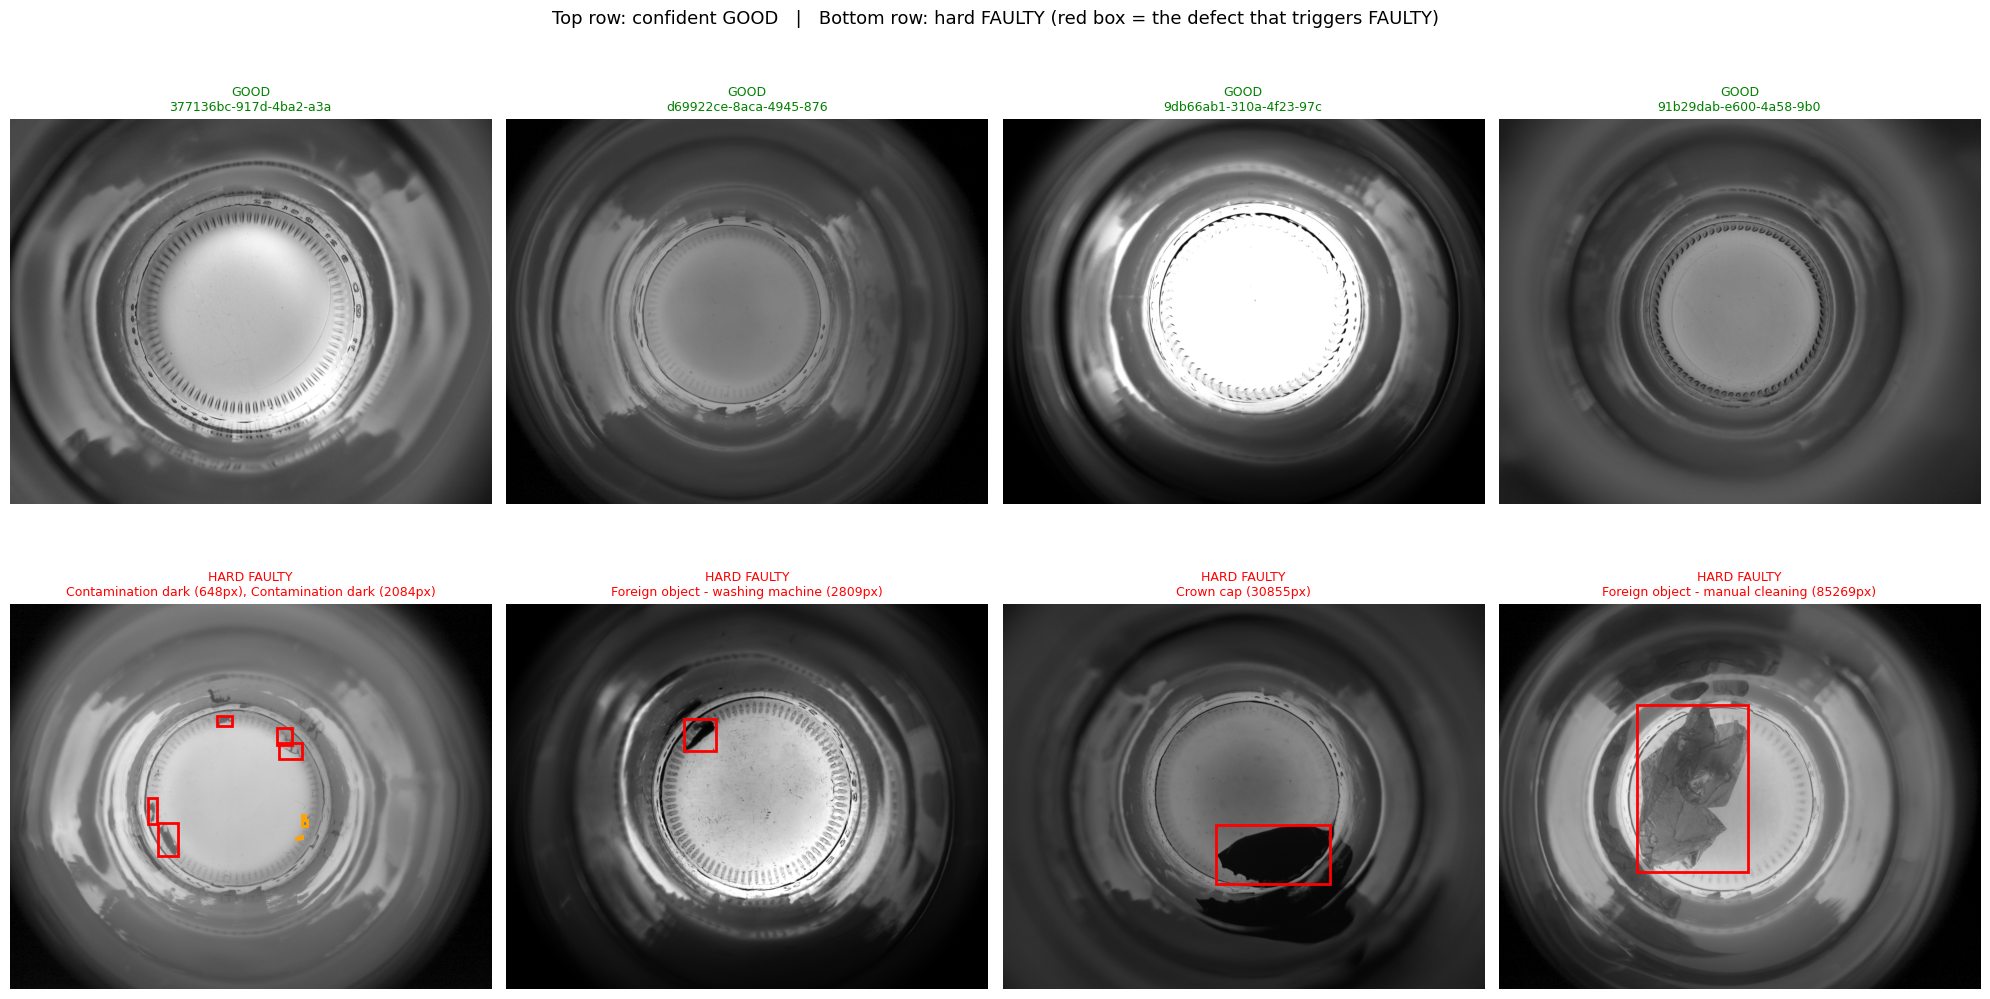


Look at the red boxes on the bottom row.
Ask yourself, honestly: can you tell these are FAULTY vs the clean GOOD bottles above?
  - If YES, the signal is in the pixels -> a stronger detector / ROI-crop can help.
  - If you CAN'T reliably tell -> you're at the dataset's ceiling; 0.98 isn't
    reachable from these images alone, and ~0.96 with that finding is the honest result.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np
import random

random.seed(CONFIG["seed"])
images_root = test_images_path.resolve()

# ── Pick 4 confident-GOOD and 4 HARD-FAULTY bottles ────────────────────────
good_pool = [f for f in (test_files if 'test_files' in dir() else all_files)
             if true_binary[f] == 0 and (images_root / f).exists()]

# Try to get *hard* faulty = true FAULTY the model scored low (most informative).
# Falls back to random FAULTY if no model/predictions are available yet.
hard_faulty_pool = []
try:
    eval_set = test_files if 'test_files' in dir() else all_files
    conf_for_pick = BEST_CONF if 'BEST_CONF' in dir() else 0.25
    scored = predict_binary_for_files(
        best if 'best' in dir() else model,
        eval_set, images_root, conf=conf_for_pick, return_scores=True)
    # hard = truly FAULTY but predicted GOOD, or flagged only with low score
    hard_faulty_pool = sorted(
        [f for f in eval_set
         if f in scored and true_binary[f] == 1
         and (scored[f][0] == 0 or scored[f][1] < 0.35)],
        key=lambda f: scored[f][1])  # lowest score = hardest first
    print(f"Hard-FAULTY pool (model-missed / low-score): {len(hard_faulty_pool)}")
except Exception as e:
    print(f"(No model predictions available — using random FAULTY. {e})")

if not hard_faulty_pool:
    hard_faulty_pool = [f for f in (test_files if 'test_files' in dir() else all_files)
                        if true_binary[f] == 1 and (images_root / f).exists()]
    random.shuffle(hard_faulty_pool)

good_sel  = random.sample(good_pool, min(4, len(good_pool)))
hard_sel  = hard_faulty_pool[:4]

# ── Draw, with the FAULTY-triggering boxes overlaid on the hard ones ───────
cond_norm_v   = {norm_name(k): v for k, v in CONFIG["conditional_thresholds"].items()}
always_norm_v = {norm_name(x) for x in CONFIG["always_faulty_labels"]}

def triggering_boxes(fname):
    """Return [(label, bbox, area, is_trigger)] for an image's GT annotations."""
    out = []
    for catid, bbox, area in img_anns.get(fname, []):
        nm = norm_name(catid_to_name.get(catid, ""))
        trig = (nm in always_norm_v) or (nm in cond_norm_v and area > cond_norm_v[nm])
        out.append((catid_to_name.get(catid, "?"), bbox, area, trig))
    return out

fig, axes = plt.subplots(2, 4, figsize=(20, 11))

for col, f in enumerate(good_sel):
    img = Image.open(images_root / f).convert("RGB")
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"GOOD\n{f[:22]}", fontsize=9, color="green")
    axes[0, col].axis("off")

for col, f in enumerate(hard_sel):
    img = Image.open(images_root / f).convert("RGB")
    axes[1, col].imshow(img)
    # overlay the GT box(es) that make it FAULTY so you know where to look
    labels_here = []
    for lbl, (x, y, w, h), area, trig in triggering_boxes(f):
        color = "red" if trig else "orange"
        axes[1, col].add_patch(mpatches.Rectangle(
            (x, y), w, h, fill=False, edgecolor=color, linewidth=2))
        if trig:
            labels_here.append(f"{lbl} ({int(area)}px)")
    sc = ""
    if 'scored' in dir() and f in scored:
        sc = f"  model_score={scored[f][1]:.2f}"
    axes[1, col].set_title(
        f"HARD FAULTY{sc}\n" + (", ".join(labels_here[:2]) if labels_here else "?"),
        fontsize=9, color="red")
    axes[1, col].axis("off")

plt.suptitle("Top row: confident GOOD   |   Bottom row: hard FAULTY "
             "(red box = the defect that triggers FAULTY)", fontsize=13)
plt.tight_layout()
plt.savefig(str(CONFIG["runs_dir"] / "good_vs_hard_faulty.png"), dpi=110,
            bbox_inches="tight")
plt.show()

# Print the verdict prompt
print("\nLook at the red boxes on the bottom row.")
print("Ask yourself, honestly: can you tell these are FAULTY vs the clean GOOD bottles above?")
print("  - If YES, the signal is in the pixels -> a stronger detector / ROI-crop can help.")
print("  - If you CAN'T reliably tell -> you're at the dataset's ceiling; 0.98 isn't")
print("    reachable from these images alone, and ~0.96 with that finding is the honest result.")

## 11 — Submission (measures area from PREDICTED boxes — no test annotations needed)

This is the payoff of the detection approach: the competition test set ships only the ROI box,
but we derive defect areas from the model's own predictions, so the 3-tier rule still applies.
Set `SUBMISSION_CONF` to the value chosen from the recall-floor table for your recall target.

In [35]:
import pandas as pd, glob, torch, gc
from pathlib import Path

gc.collect(); torch.cuda.empty_cache()

SUBMISSION_CONF = 0.30
OUTPUT_FILE = "submission.csv"
CHUNK = 16

# Prefer the authoritative image list from the test annotations JSON (keeps the
# exact set + lets us order deterministically). Fall back to globbing the folder.
test_files = []
if CONFIG["test_coco_json"].exists():
    with open(CONFIG["test_coco_json"]) as f:
        tc = json.load(f)
    test_files = [Path(im["file_name"]).name for im in tc.get("images", [])]
if not test_files:
    test_files = [Path(p).name for p in glob.glob(str(CONFIG["test_images_dir"] / "*.png"))]
print(f"Found {len(test_files)} test images on disk. Sorting them for consistent order...")
# Order by the numeric suffix after the last underscore (matches the sample format).
def seq_key(fn):
    stem = Path(fn).stem
    tail = stem.split("_")[-1]
    return int(tail) if tail.isdigit() else fn
test_files = sorted(test_files, key=seq_key)
print(f"Test images to predict: {len(test_files)}")

# Predict in chunks, keyed by filename so we can guarantee one row per image.
pred = {}
for i in tqdm.tqdm(range(0, len(test_files), CHUNK)):
    batch_files = test_files[i:i + CHUNK]
    batch_paths = [str(CONFIG["test_images_dir"] / f) for f in batch_files]
    # only predict files that actually exist on disk
    exist_pairs = [(f, p) for f, p in zip(batch_files, batch_paths) if Path(p).exists()]
    if not exist_pairs:
        continue
    fs, ps = zip(*exist_pairs)
    results = best.predict(list(ps), conf=SUBMISSION_CONF, iou=0.6,
                           imgsz=CONFIG["imgsz"], device=CONFIG["device"],
                           verbose=False, stream=False)
    for fname, r in zip(fs, results):
        faulty = 0
        img_path = CONFIG["test_images_dir"] / fname   # build the real path from fname
        if is_no_base_visible(img_path):
            faulty = 1
        elif r.boxes is not None and len(r.boxes) > 0:
            cls  = r.boxes.cls.cpu().numpy().astype(int)
            xywh = r.boxes.xywh.cpu().numpy()
            for c, (bx, by, bw, bh) in zip(cls, xywh):
                nm = yolo_to_norm.get(int(c), "")
                area = float(bw * bh)
                if (nm in always_norm) or (nm in cond_norm and area > cond_norm[nm]):
                    faulty = 1
                    break
        # sub.append({"image_id": fname, "target": faulty})
        pred[fname] = faulty
    del results
torch.cuda.empty_cache()

# Build the dataframe in the required order; default any missing image to 0 (GOOD)
missing = [f for f in test_files if f not in pred]
if missing:
    print(f"WARNING: {len(missing)} test images had no prediction (image not found on disk?) "
          f"— defaulting them to 0. First few: {missing[:3]}")
rows = [{"image_id": f, "target": int(pred.get(f, 0))} for f in test_files]

df = pd.DataFrame(rows, columns=["image_id", "target"])
df.to_csv(OUTPUT_FILE, index=False)

nf = int(df["target"].sum())
print(f"Saved {OUTPUT_FILE}: {len(df)} rows | FAULTY={nf} ({100*nf/max(len(df),1):.1f}%) | GOOD={len(df)-nf}")
print(df.head().to_string(index=False))

# count the number of images in the test_images folder
test_images_count = len(list(Path('/home/dll0706/Documents/Bakwowi_Junior_CV_Project/1st-krones-vision-ai-challenge/test_images').glob("*.png")))
print(f"Number of images in test_images folder: {test_images_count}")

Found 4418 test images on disk. Sorting them for consistent order...
Test images to predict: 4418


  0%|          | 0/277 [00:00<?, ?it/s]

100%|██████████| 277/277 [01:58<00:00,  2.33it/s]

Saved submission.csv: 4418 rows | FAULTY=2394 (54.2%) | GOOD=2024
                                             image_id  target
64e50373-1f39-40e7-b821-655246c7a30e_000000000001.png       1
43b0c8b4-75b6-40b2-b867-ea2779f6ecec_000000000002.png       1
50269c78-2962-42a0-ac21-e83155eaeeb3_000000000003.png       0
a13c8c3d-ace7-4b58-8a25-697e6d3d4bc5_000000000004.png       0
0f06081b-03f9-4179-ab26-cd402f40e43c_000000000005.png       1
Number of images in test_images folder: 4420


In [26]:
from pathlib import Path

# The 84 names the JSON expects
expected = set(test_files)
# What's actually on disk
on_disk = {p.name for p in CONFIG["test_images_dir"].glob("*.png")}
on_disk_all = {p.name for p in CONFIG["test_images_dir"].glob("*")}  # any extension

missing = sorted(expected - on_disk)
print(f"Missing as .png: {len(missing)}")
print(f"Files on disk (.png): {len(on_disk)} | (any ext): {len(on_disk_all)}")

# Cause 1: extension mismatch (JSON says .png, disk has .jpg/.jpeg/.PNG)
for m in missing[:5]:
    stem = Path(m).stem
    alts = [p.name for p in CONFIG["test_images_dir"].glob(f"{stem}.*")]
    print(f"  {m}  -> on disk as: {alts}")

# Cause 2: images in a subfolder rather than flat
subdir_hits = list(CONFIG["test_images_dir"].rglob(missing[0])) if missing else []
print(f"Recursive search for first missing: {subdir_hits}")

# Cause 3: total counts
print(f"JSON lists {len(test_files)} images; disk has {len(on_disk_all)} files")

Missing as .png: 84
Files on disk (.png): 4334 | (any ext): 4334
  00050d96-644f-4f14-89d5-eb9cd1c05f55_000000001443.png  -> on disk as: []
  000afea1-bb78-44e4-ad6c-6012654e01f8_000000001316.png  -> on disk as: []
  001e4854-e423-46ba-857d-2027d042f4e9_000000000650.png  -> on disk as: []
  001fd503-6291-4d69-b421-8ad371086a6a_000000000177.png  -> on disk as: []
  0043e53f-59a6-4804-a52a-85a4126540eb_000000003842.png  -> on disk as: []
Recursive search for first missing: []
JSON lists 4418 images; disk has 4334 files


In [45]:
import time, glob, statistics, torch
from pathlib import Path
from ultralytics import YOLO

# ── Config ──────────────────────────────────────────────────────────────
PT_WEIGHTS  = Path('./runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/weights/best.pt')  # your best.pt
N_WARMUP    = 10        # discarded — covers CUDA/cuDNN autotuning
N_MEASURE   = 200       # timed images; more = stabler median
IMGSZ_LIST  = [1280, 960, 768]   # sweep: efficiency vs the resolution you trained at
DEVICE      = 0

# Grab a sample of real test images (real images, not random tensors —
# decode + preprocess cost is part of the runtime the organizers measure)
sample_paths = sorted(glob.glob(str(CONFIG["test_images_dir"] / "*.png")))[:N_WARMUP + N_MEASURE]
assert len(sample_paths) >= N_WARMUP + N_MEASURE, \
    f"Need >= {N_WARMUP + N_MEASURE} images, found {len(sample_paths)}"
warmup_paths  = sample_paths[:N_WARMUP]
measure_paths = sample_paths[N_WARMUP:N_WARMUP + N_MEASURE]


def time_model(model, imgsz, label):
    """Median + p90 per-image latency, batch=1, with proper GPU sync and warmup."""
    # Warmup — autotuning happens here, not in the timed loop
    for p in warmup_paths:
        model.predict(p, imgsz=imgsz, device=DEVICE, verbose=False)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    per_image = []
    for p in measure_paths:
        if torch.cuda.is_available():
            torch.cuda.synchronize()        # ensure prior work is done
        t0 = time.perf_counter()
        model.predict(p, imgsz=imgsz, device=DEVICE, verbose=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()        # wait for THIS inference to finish
        per_image.append((time.perf_counter() - t0) * 1000)  # ms

    per_image.sort()
    median = statistics.median(per_image)
    p90    = per_image[int(0.9 * len(per_image))]
    mean   = statistics.mean(per_image)
    print(f"{label:28s} imgsz={imgsz:4d} | "
          f"median={median:6.1f}ms  mean={mean:6.1f}ms  p90={p90:6.1f}ms  "
          f"| throughput={1000/median:5.1f} img/s")
    return median


print("=" * 78)
print("PYTORCH (.pt) — resolution sweep")
print("=" * 78)
pt_model = YOLO(PT_WEIGHTS)
pt_results = {}
for sz in IMGSZ_LIST:
    pt_results[sz] = time_model(pt_model, sz, "PyTorch .pt")

# ── ONNX export + timing (they accept ONNX) ────────────────────────────────
print("\n" + "=" * 78)
print("ONNX — same resolution sweep (export once per imgsz)")
print("=" * 78)
onnx_results = {}
for sz in IMGSZ_LIST:
    # ONNX graph is fixed-resolution: export one engine per imgsz you test.
    # half=True for FP16; simplify=True cleans the graph.
    onnx_path = pt_model.export(format="onnx", imgsz=sz, half=True,
                                simplify=True, dynamic=False, device=DEVICE)
    onnx_model = YOLO(onnx_path)
    onnx_results[sz] = time_model(onnx_model, sz, "ONNX (fp16)")

# ── Summary: the trade you actually care about ─────────────────────────────
print("\n" + "=" * 78)
print("SUMMARY — speedup vs your trained config (PyTorch @1280)")
print("=" * 78)
baseline = pt_results[1280]
print(f"{'config':30s} {'median ms':>10s} {'speedup':>9s}")
for sz in IMGSZ_LIST:
    print(f"{'PyTorch @'+str(sz):30s} {pt_results[sz]:10.1f} {baseline/pt_results[sz]:8.2f}x")
for sz in IMGSZ_LIST:
    print(f"{'ONNX fp16 @'+str(sz):30s} {onnx_results[sz]:10.1f} {baseline/onnx_results[sz]:8.2f}x")
print("\nNote: organizers measure TOTAL runtime on their set in THEIR Kaggle env.")
print("These numbers are RELATIVE — use them to choose config, not as absolute scores.")

PYTORCH (.pt) — resolution sweep
PyTorch .pt                  imgsz=1280 | median=  15.7ms  mean=  15.3ms  p90=  16.5ms  | throughput= 63.7 img/s
PyTorch .pt                  imgsz= 960 | median=  15.7ms  mean=  15.3ms  p90=  16.6ms  | throughput= 63.6 img/s
PyTorch .pt                  imgsz= 768 | median=  15.1ms  mean=  14.7ms  p90=  16.0ms  | throughput= 66.2 img/s

ONNX — same resolution sweep (export once per imgsz)
Ultralytics 8.4.56 🚀 Python-3.13.9 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX A5000, 24114MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/weights/best.pt' with input shape (1, 3, 1280, 1280) BCHW and output shape(s) (1, 300, 6) (5.3 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [onnxs

/home/dll0706/Documents/Bakwowi_Junior_CV_Project/.conda_venv/lib/python3.13/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 18 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success ✅ 2.5s, saved as 'runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/weights/best.onnx' (5.0 MB)

Export complete (2.5s)
Results saved to /home/dll0706/Documents/Bakwowi_Junior_CV_Project/runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/weights/best.onnx imgsz=1280 half
Validate:        yolo val task=detect model=runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/weights/best.onnx imgsz=1280 data=1st-krones-vision-ai-challenge/yolo_ds/bottle.yaml half 
Visualize:       https://netron.app
Loading runs/detect/1st-krones-vision-ai-challenge/runs/yolo26n_bottle_1280/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider


2026-06-02 11:47:26.007227412 [E:onnxruntime:Default, provider_bridge_ort.cc:2369 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1962 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/dll0706/Documents/Bakwowi_Junior_CV_Project/.conda_venv/lib/python3.13/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory



RuntimeError: Error when binding input: There's no data transfer registered for copying tensors from Device:[DeviceType:1 MemoryType:0 VendorId:4318 DeviceId:0 Alignment:0] to Device:[DeviceType:0 MemoryType:0 VendorId:0 DeviceId:0 Alignment:0]

In [46]:
# Ultralytics reports a per-stage breakdown. Run a few and read the speed dict.
pt_model = YOLO(model)
# warmup
for p in measure_paths[:10]:
    pt_model.predict(p, imgsz=1280, device=DEVICE, verbose=False)

import numpy as np
stages = {"preprocess": [], "inference": [], "postprocess": []}
for p in measure_paths[:100]:
    r = pt_model.predict(p, imgsz=1280, device=DEVICE, verbose=False)
    s = r[0].speed   # {'preprocess':, 'inference':, 'postprocess':} in ms
    for k in stages:
        stages[k].append(s[k])
for k, v in stages.items():
    print(f"{k:12s} median={np.median(v):6.2f}ms")
print(f"{'SUM':12s} median={sum(np.median(v) for v in stages.values()):6.2f}ms")

preprocess   median=  2.00ms
inference    median=  5.71ms
postprocess  median=  0.22ms
SUM          median=  7.93ms


In [47]:
import time, torch
pt_model = YOLO(model)
batch = [str(p) for p in measure_paths[:64]]
# warmup
pt_model.predict(batch[:16], imgsz=1280, device=DEVICE, verbose=False)
torch.cuda.synchronize()

for bs in [1, 8, 16, 32]:
    sub = batch[:bs]
    torch.cuda.synchronize(); t0 = time.perf_counter()
    for _ in range(5):
        pt_model.predict(sub, imgsz=1280, device=DEVICE, verbose=False, batch=bs)
    torch.cuda.synchronize()
    per_img = (time.perf_counter() - t0) / (5 * bs) * 1000
    print(f"batch={bs:3d}: {per_img:6.2f} ms/img")

batch=  1:  23.53 ms/img
batch=  8:  19.01 ms/img
batch= 16:  18.14 ms/img
batch= 32:  18.31 ms/img


## 12 — Reading the result

**If the recall≥0.99 row beats ~0.95–0.96:** the detection approach is extracting signal the
classifier couldn't, and pushing `imgsz` to 1536 + more epochs is worth it. The area-measurement
hypothesis is working.

**If it sits at or below the classifier's 0.9456:** look at cell 10. If `contamination dark` /
`scuffing` dominate the missed-FAULTY categories, the detector cannot localize those patches any
better than the classifier could separate them — which is strong evidence the **dataset's ceiling
is the information in the pixels**, not the model. At that point the defensible, honest deliverable
is the ~0.96 result with this diagnosis attached, rather than more architecture churn.

Either outcome is *definitive* in the sense you wanted: it tells you which world you're in.

**Knobs, in order of leverage:** (1) the per-category area thresholds in CONFIG applied to
predicted boxes — these directly set FP/FN trade; (2) `imgsz`; (3) `SUBMISSION_CONF` / the conf
floor; (4) `rare_repeat_factor`. Reweighting and threshold churn on a fixed model — the things
that plateaued before — are deliberately *not* the levers here.